# Entity-Aware Financial News Sentiment Classification

Final project for *Natural Language Processing and Text Analytics (KAN-CDSCO1002U)* at CBS.

**Task**: Aspect-Based Sentiment Analysis (ABSA) — classify sentiment (positive / negative / neutral) towards a named entity in a financial news headline.
**Dataset**: SEntFiN 1.0 (Sinha et al., 2023) — 10,753 headlines with 14,404 entity-sentiment annotations.
**Models**: TF-IDF + Naive Bayes, TF-IDF + Logistic Regression, VADER, Word2Vec + Logistic Regression, FinBERT, Local LLM, GPT zero-shot.

## Setup

In [69]:
%pip install pandas numpy nltk spacy scikit-learn seaborn matplotlib gensim torch transformers

  Using cached transformers-5.8.0-py3-none-any.whl.metadata (33 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 3.1 MB/s  0:00:03m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 1.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 2.3 MB/s  0:00:01 eta 0:00:01
Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl (173 kB)
Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl (447 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [transformers] [transformers]ub]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need

In [ ]:
import ast
import sys
import re
import time
import os
from collections import Counter
import pandas as pd
import numpy as np
import nltk
import spacy
import nobodywho
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
# OUTSIDE COURSE SCOPE: transformers used for FinBERT inference.
# Not available in course tools; included to benchmark a domain-specific pre-trained model.
from transformers import pipeline as hf_pipeline

In [26]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/henriklangfeldt/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/henriklangfeldt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/henriklangfeldt/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## 1. Data

We use SEntFiN 1.0 (Sinha et al., 2023), a human-annotated dataset of 10,753 financial news headlines sourced from The Economic Times (2011-2015). Each headline is annotated for one or more named entities (companies, sectors, commodities) with a sentiment label — positive, negative, or neutral — assigned by three independent human annotators using a consensus-driven process.

Because a single headline can mention multiple entities with potentially conflicting sentiments, each entity-sentiment pair is treated as a separate instance. This gives 14,404 instances in total.

The dataset is loaded directly from the official GitHub repository.

In [4]:
df_raw = pd.read_csv('https://raw.githubusercontent.com/pyRis/SEntFiN/main/SEntFiN.csv')

print(f"Headlines: {len(df_raw)}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)

Headlines: 10753
Columns: ['S No.', 'Title', 'Decisions', 'Words']


,S No.,Title,Decisions,Words
0,1,SpiceJet to issue 6.4 crore warrants to promoters,{'SpiceJet': 'neutral'},8
1,2,MMTC Q2 net loss at Rs 10.4 crore,{'MMTC': 'neutral'},8
2,3,"Mid-cap funds can deliver more, stay put: Experts",{'Mid-cap funds': 'positive'},8


In [5]:
def parse_decisions(s):
    # ast.literal_eval breaks on apostrophes in entity names (e.g. "Osian's Art Fund")
    # so we match key-value pairs by anchoring on the known sentiment values instead
    return dict(re.findall(r"'([\w\s'&.()\-]+)':\s*'(positive|negative|neutral)'", s))

rows = []
for _, row in df_raw.iterrows():
    decisions = parse_decisions(row['Decisions'])
    for entity, sentiment in decisions.items():
        rows.append({
            'headline': row['Title'],
            'entity': entity,
            'sentiment': sentiment
        })

df = pd.DataFrame(rows)
print(f"Total instances: {len(df)}")
print(f"Unique headlines: {df['headline'].nunique()}")
print(f"Multi-entity headlines: {(df_raw['Decisions'].apply(lambda x: len(parse_decisions(x))) > 1).sum()}")
df.head()

Total instances: 14389
Unique headlines: 10677
Multi-entity headlines: 2842


,headline,entity,sentiment
0,SpiceJet to issue 6.4 crore warrants to promoters,SpiceJet,neutral
1,MMTC Q2 net loss at Rs 10.4 crore,MMTC,neutral
2,"Mid-cap funds can deliver more, stay put: Experts",Mid-cap funds,positive
3,Mid caps now turn into market darlings,Mid caps,positive
4,"Market seeing patience, if not conviction: Pra...",Market,neutral


sentiment
neutral     5510
positive    5070
negative    3809
Name: count, dtype: int64

Total instances: 14389


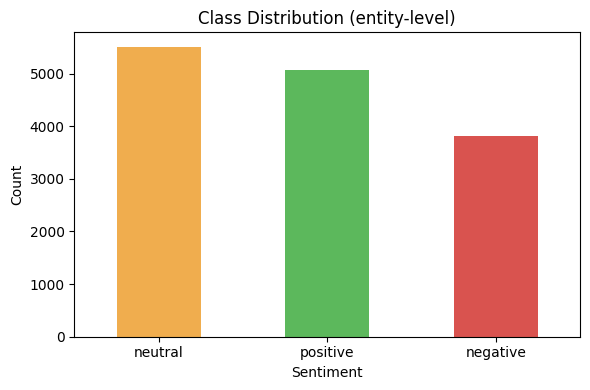

In [6]:
print(df['sentiment'].value_counts())
print(f"\nTotal instances: {len(df)}")

color_map = {'positive': '#5cb85c', 'negative': '#d9534f', 'neutral': '#f0ad4e'}
counts = df['sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=[color_map[l] for l in counts.index])
ax.set_title('Class Distribution (entity-level)')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### Data Description

**Dataset**: SEntFiN 1.0 (Sinha, Kedas, Kumar & Malo, 2023)

| Property | Value |
|---|---|
| Source | The Economic Times (Indian financial news, 2011-2015) |
| Headlines | 10,753 |
| Entity-sentiment instances | 14,404 |
| Multi-entity headlines | 2,847 (26.5%) |
| Average headline length | 9.91 words |
| Annotation | 3 independent human annotators, consensus-driven |

**Class distribution (entity-level)**:

| Sentiment | Count | Share |
|---|---|---|
| Neutral | 5,516 | 38.3% |
| Positive | 5,074 | 35.2% |
| Negative | 3,814 | 26.5% |

The class distribution is substantially more balanced than sentence-level financial sentiment datasets such as financial_phrasebank, which has a neutral majority of ~59%. The relatively even split across classes reduces the need for class weighting in training.

Each instance consists of a headline, a target entity, and a sentiment label. Headlines with multiple entities produce one instance per entity, allowing the same headline to carry conflicting sentiments — for example, a headline about an acquisition may be positive for the acquiree and negative for the acquirer. Sample rows:

| Headline | Entity | Sentiment |
|---|---|---|
| SpiceJet to issue 6.4 crore warrants to promoters | SpiceJet | neutral |
| MMTC Q2 net loss at Rs 10.4 crore | MMTC | neutral |
| Mid-cap funds can deliver more, stay put: Experts | Mid-cap funds | positive |

### Data Cleaning

Check that each annotated entity actually appears in its headline. Rows where the entity cannot be found are likely annotation errors and will be flagged and removed before preprocessing.

In [ ]:
# Some annotated entities do not appear in their headline due to annotation errors
# (e.g. 'L&T Finance neutralings' instead of 'L&T Finance Holdings').
# These rows are dropped as the substitution step cannot locate the entity in the text.
df['entity_in_headline'] = df.apply(
    lambda row: row['entity'].lower() in row['headline'].lower(), axis=1
)

flagged = df[~df['entity_in_headline']]
print(f"Removed {len(flagged)} rows where entity not found in headline ({len(flagged)/len(df):.1%})")

df = df[df['entity_in_headline']].drop(columns='entity_in_headline').reset_index(drop=True)
print(f"Remaining instances: {len(df)}")

## 2. Preprocessing

### 2.1 Named Entity Recognition

We use spaCy NER to detect entity spans in raw headlines. The dataset annotations serve only as ground truth labels (y) — they are not used to guide entity detection. This keeps the pipeline applicable to any unseen headline.

In [ ]:
!python -m spacy download en_core_web_lg

nlp = spacy.load("en_core_web_lg")

# Run NER on all unique headlines in one pass
unique_headlines = df_raw['Title'].tolist()
headline_to_ents = {}
for doc in nlp.pipe(unique_headlines, batch_size=64):
    headline_to_ents[doc.text] = [ent.text for ent in doc.ents]

total_detected = sum(len(v) for v in headline_to_ents.values())
headlines_with_ents = sum(1 for v in headline_to_ents.values() if len(v) > 0)
print(f"Headlines processed: {len(unique_headlines)}")
print(f"Headlines with at least one entity detected: {headlines_with_ents} ({headlines_with_ents/len(unique_headlines):.1%})")
print(f"Total entity spans detected: {total_detected}")

# Preview
sample = list(headline_to_ents.items())[:5]
for headline, ents in sample:
    print(f"\n  '{headline}'\n  -> {ents}")

### 2.2 Sanity Check: spaCy vs Dataset Annotations

For each annotated (headline, entity) pair, we check whether spaCy detected that entity (or a span overlapping it). This measures how much signal is lost due to NER errors before we commit to using spaCy detections for substitution.

In [ ]:
def entity_matched(annotated, detected_list):
    """True if annotated entity overlaps (substring) with any detected span."""
    a = annotated.lower().strip()
    return any(a in d.lower() or d.lower() in a for d in detected_list)

# Recall: of all annotated entities, how many did spaCy find?
matched = 0
missed = []
for _, row in df.iterrows():
    detected = headline_to_ents.get(row['headline'], [])
    if entity_matched(row['entity'], detected):
        matched += 1
    else:
        missed.append((row['headline'], row['entity'], detected))

recall = matched / len(df)

# Precision: of all spaCy detections, how many match the entity column in df?
# Count detections per unique headline to avoid inflating with multi-entity rows
entities_by_headline = df.groupby('headline')['entity'].apply(list).to_dict()

correct_detections = 0
total_detections = 0
for headline, detected_list in headline_to_ents.items():
    annotated_list = [e.lower() for e in entities_by_headline.get(headline, [])]
    for detected in detected_list:
        total_detections += 1
        d = detected.lower()
        if any(a in d or d in a for a in annotated_list):
            correct_detections += 1

precision = correct_detections / total_detections if total_detections > 0 else 0

print(f"Recall:    {matched}/{len(df)} ({recall:.1%}) — annotated entities found by spaCy")
print(f"Precision: {correct_detections}/{total_detections} ({precision:.1%}) — spaCy detections matching the entity column in df")
print(f"Missed: {len(missed)}")

print("\nSample missed cases (headline | annotated entity | spaCy detected):")
for headline, entity, detected in missed[:10]:
    print(f"  '{headline}'\n  annotated: '{entity}' | detected: {detected}\n")

### 2.2 Target/Other Substitution via String Matching

spaCy NER reached only 64.7% recall because commodities, sectors, and generic financial terms fall outside standard NER categories. We instead locate entities using case-insensitive string matching against the annotated entity names, giving 100% coverage across all entity types.

For each instance (headline, focal entity), the focal entity is replaced with `Target` and all other entities in the same headline are replaced with `Other`. Entities are sorted longest-first before substitution to prevent shorter entities from matching inside longer ones.

In [ ]:
entities_by_headline = df.groupby('headline')['entity'].apply(list).to_dict()

def substitute_entities(headline, focal_entity, all_entities):
    # Sort longest first to prevent shorter entities matching inside longer ones
    sorted_entities = sorted(all_entities, key=len, reverse=True)
    text = headline
    for entity in sorted_entities:
        replacement = 'Target' if entity.lower() == focal_entity.lower() else 'Other'
        text = re.sub(re.escape(entity), replacement, text, flags=re.IGNORECASE)
    return text

df['substituted'] = df.apply(
    lambda row: substitute_entities(
        row['headline'],
        row['entity'],
        entities_by_headline[row['headline']]
    ),
    axis=1
)

print(f"Instances with 'Target' in substituted headline: {df['substituted'].str.contains('Target').sum()}/{len(df)}")

print("\nSample substitutions:")
for _, row in df.head(8).iterrows():
    print(f"  original:     '{row['headline']}'")
    print(f"  entity:       '{row['entity']}'")
    print(f"  substituted:  '{row['substituted']}'")
    print()

# FIX THE MISSING 3 VALUES HERE 

Instances with 'Target' in substituted headline: 14367/14370

Sample substitutions:
  original:     'SpiceJet to issue 6.4 crore warrants to promoters'
  entity:       'SpiceJet'
  substituted:  'Target to issue 6.4 crore warrants to promoters'

  original:     'MMTC Q2 net loss at Rs 10.4 crore'
  entity:       'MMTC'
  substituted:  'Target Q2 net loss at Rs 10.4 crore'

  original:     'Mid-cap funds can deliver more, stay put: Experts'
  entity:       'Mid-cap funds'
  substituted:  'Target can deliver more, stay put: Experts'

  original:     'Mid caps now turn into market darlings'
  entity:       'Mid caps'
  substituted:  'Target now turn into market darlings'

  original:     'Market seeing patience, if not conviction: Prakash Diwan'
  entity:       'Market'
  substituted:  'Target seeing patience, if not conviction: Prakash Diwan'

  original:     'Infosys: Will the strong volume growth sustain?'
  entity:       'Infosys'
  substituted:  'Target: Will the strong volume growth

### 2.3 Tokenization and Punctuation Removal

Lowercase, tokenize with `word_tokenize`, and remove non-alphabetic tokens. Stop words are kept — the paper does not remove them for lexicon-based and BoW models.

In [ ]:
def preprocess(text):                                                    
    tokens = word_tokenize(text)
    return ' '.join(t for t in tokens if t.isalnum() or                  
                re.match(r'^\d+\.\d+$', t))  

df['processed'] = df['substituted'].apply(preprocess)

print("Sample:")
for _, row in df.head(5).iterrows():
    print(f"  substituted: '{row['substituted']}'")
    print(f"  processed:   '{row['processed']}'")
    print() #heøøøø

Sample:
  substituted: 'Target to issue 6.4 crore warrants to promoters'
  processed:   'Target to issue 6.4 crore warrants to promoters'

  substituted: 'Target Q2 net loss at Rs 10.4 crore'
  processed:   'Target Q2 net loss at Rs 10.4 crore'

  substituted: 'Target can deliver more, stay put: Experts'
  processed:   'Target can deliver more stay put Experts'

  substituted: 'Target now turn into market darlings'
  processed:   'Target now turn into market darlings'

  substituted: 'Target seeing patience, if not conviction: Prakash Diwan'
  processed:   'Target seeing patience if not conviction Prakash Diwan'



### 2.4 Train/Test Split

80/20 split, stratified by sentiment class to preserve class distribution. All models use this same split.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    df['processed'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)

train_sentences = [text.split() for text in X_train]
test_sentences  = [text.split() for text in X_test]

# Raw headlines and entity names aligned with test split — used by LLM models
test_df       = df.loc[X_test.index, ['headline', 'entity']].reset_index(drop=True)
y_test_reset  = y_test.reset_index(drop=True)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nClass distribution — train:\n{y_train.value_counts()}")
print(f"\nClass distribution — test:\n{y_test.value_counts()}")

Train: 11496 | Test: 2874

Class distribution — train:
sentiment
neutral     4399
positive    4052
negative    3045
Name: count, dtype: int64

Class distribution — test:
sentiment
neutral     1100
positive    1013
negative     761
Name: count, dtype: int64


## 3. Exploratory Data Analysis

### 3.1 Word Frequency by Sentiment Class

Most frequent words in Target-substituted headlines per sentiment class. `Target` and `Other` are excluded as they are substitution tokens, not content words.

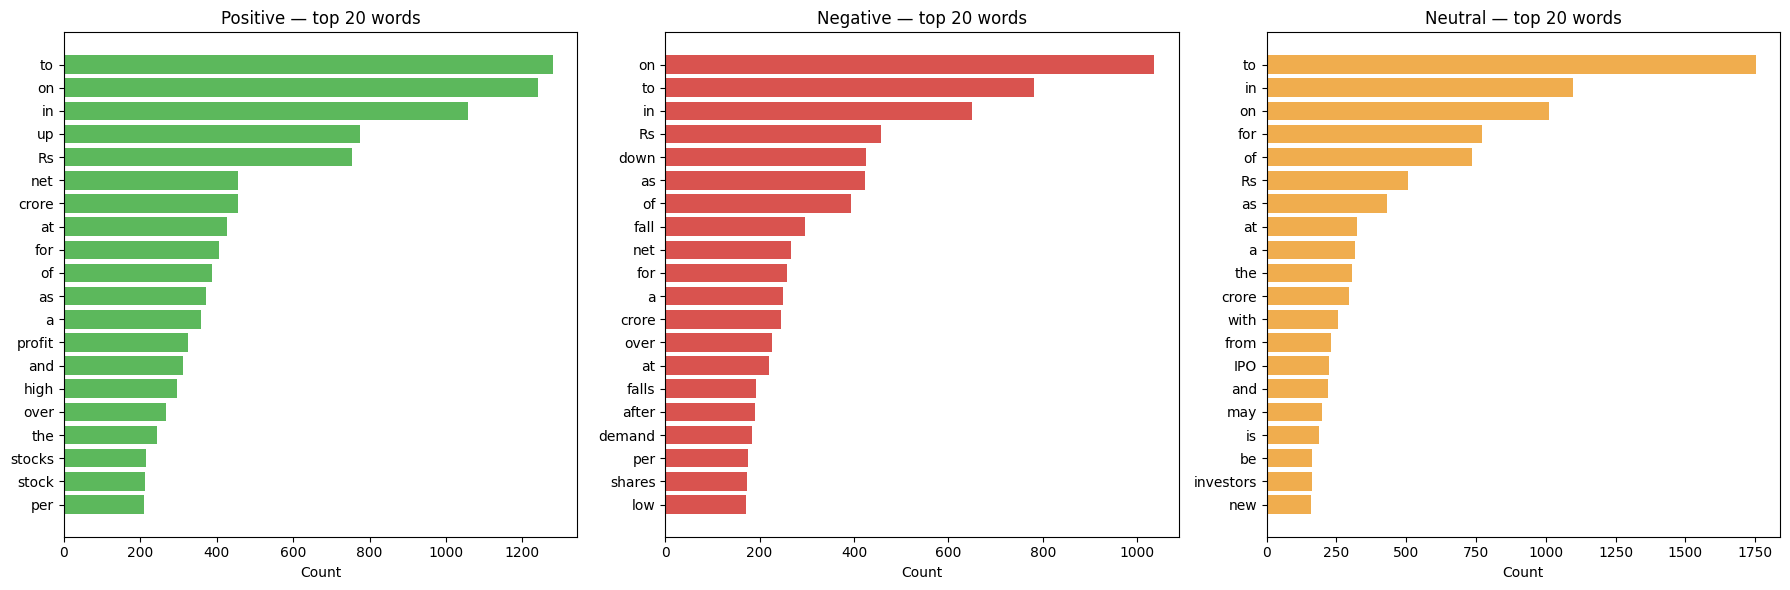

In [39]:
from collections import Counter

exclude = {'Target', 'Other'}
color_map = {'positive': '#5cb85c', 'negative': '#d9534f', 'neutral': '#f0ad4e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    tokens = []
    for text in df[df['sentiment'] == sentiment]['substituted']:
        tokens.extend(t for t in word_tokenize(text) if t.isalnum() and t not in exclude)
    top = Counter(tokens).most_common(20)
    words, counts = zip(*top)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color_map[sentiment])
    ax.set_title(f'{sentiment.capitalize()} — top 20 words')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

### 3.2 Class Distribution per Entity Type

Entities are classified into companies, sectors, and commodities using keyword matching. Class distribution is then shown per type.

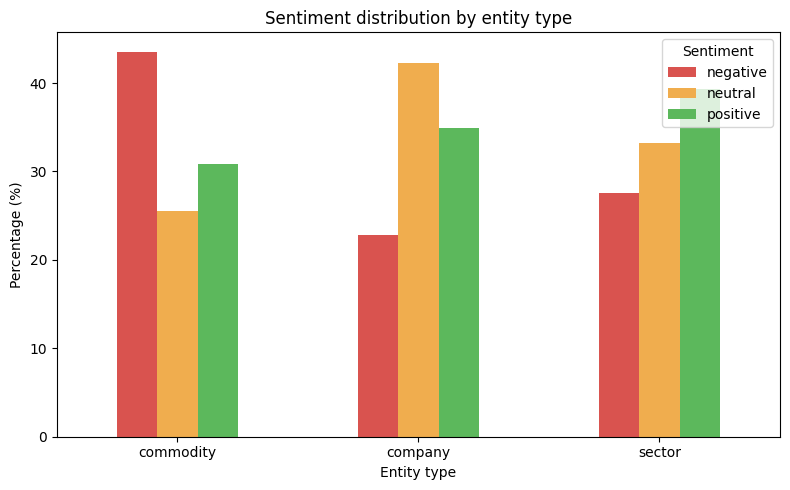


Entity type counts:
entity_type
company      9684
sector       2762
commodity    1924
Name: count, dtype: int64


In [40]:
COMMODITIES = {
    'gold', 'silver', 'oil', 'crude', 'sugar', 'wheat', 'copper', 'steel',
    'rubber', 'zinc', 'aluminium', 'aluminum', 'cotton', 'coffee', 'cocoa',
    'natural gas', 'coal', 'iron', 'nickel', 'lead', 'tin', 'gur', 'jaggery',
    'pulses', 'spices', 'pepper', 'turmeric', 'cardamom', 'mentha', 'soya',
    'brent', 'dollar', 'euro', 'yen', 'yuan', 'rupee', 'sterling'
}
SECTORS = {
    'banking', 'tech', 'pharma', 'auto', 'realty', 'fmcg', 'it', 'telecom',
    'power', 'infrastructure', 'infra', 'aviation', 'retail', 'media',
    'insurance', 'metals', 'energy', 'healthcare', 'cement', 'textile',
    'commodity', 'commodities', 'market', 'markets', 'stocks', 'equities',
    'midcap', 'smallcap', 'largecap', 'mid caps', 'small caps',
    'mid-cap funds', 'pharmaceutical sector', 'power sector'
}

def classify_entity(entity):
    e = entity.lower().strip()
    if any(c in e for c in COMMODITIES):
        return 'commodity'
    if any(s in e for s in SECTORS):
        return 'sector'
    return 'company'

df['entity_type'] = df['entity'].apply(classify_entity)

type_sentiment = df.groupby(['entity_type', 'sentiment']).size().unstack(fill_value=0)
type_sentiment_pct = type_sentiment.div(type_sentiment.sum(axis=1), axis=0) * 100

ax = type_sentiment_pct.plot(
    kind='bar', figsize=(8, 5),
    color=[color_map[c] for c in type_sentiment_pct.columns]
)
ax.set_title('Sentiment distribution by entity type')
ax.set_xlabel('Entity type')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

print(f"\nEntity type counts:\n{df['entity_type'].value_counts()}")

### 3.3 NER Label Distribution (spaCy)

What NER categories does spaCy assign to detected entities? This reveals why generic financial terms (commodities, sectors) are missed — they fall outside standard NER labels like ORG, PERSON, and GPE.

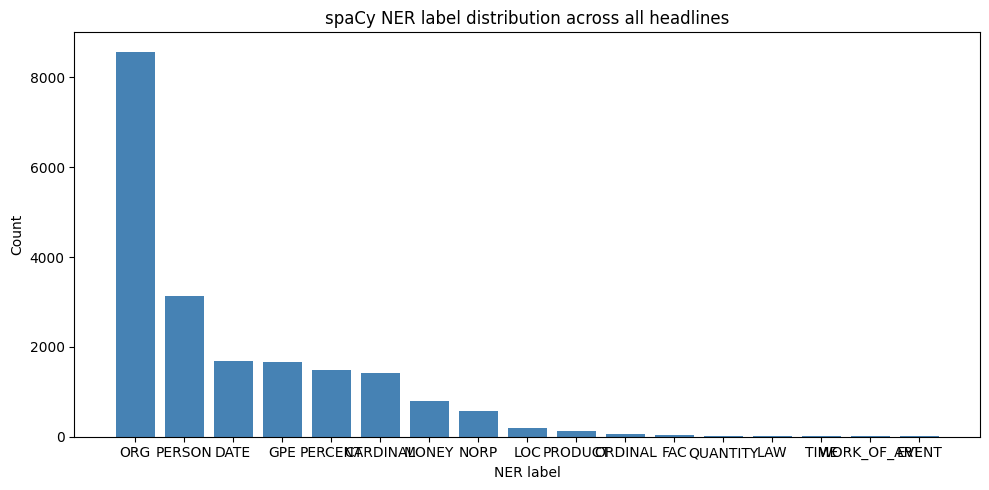

In [41]:
label_counts = Counter()
for doc in nlp.pipe(df['headline'].unique(), batch_size=64):
    for ent in doc.ents:
        label_counts[ent.label_] += 1

labels, counts = zip(*sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, counts, color='steelblue')
ax.set_title('spaCy NER label distribution across all headlines')
ax.set_xlabel('NER label')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

  - Word frequency — dominated by stop words, and the few meaningful words 
  ("profit", "up", "down") are so obvious they don't tell you anything you
  didn't already know about the data.                                      
  - Entity type distribution — the classification is based on a rough
  keyword list we wrote ourselves, so the result reflects our assumptions  
  more than the actual data. Not very credible.
  - NER label distribution — useful as a visual explanation for why spaCy  
  failed (ORG dominates, commodities/sectors have no matching label), but  
  that point is already made in the text of section 2.1.
                                                                           
  The EDA that would actually add value for this project is something like:
  - Sentiment distribution across the most frequent entities (does "Sebi"
  tend to be neutral? does "gold" tend to be negative?)                    
  - Headline length vs sentiment — do longer headlines correlate with more
  complex/neutral sentiment?                                               
  - How often do conflicting sentiments appear in the same headline?   

## 4. Models

All models receive the Target/Other substituted headline as input and are evaluated on the same 80/20 test split. Primary metric is macro F1.

A shared evaluation helper is defined once and reused across all models.

In [38]:
def evaluate(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=['negative', 'neutral', 'positive']))
    cm = confusion_matrix(y_true, y_pred, labels=['negative', 'neutral', 'positive'])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'neutral', 'positive'],
                yticklabels=['negative', 'neutral', 'positive'], ax=ax)
    ax.set_title(f'{name} — confusion matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

### 4.1 VADER

Lexicon-based baseline. Runs on the substituted headline text (not tokenized — VADER expects natural language). Compound score mapped to sentiment classes using standard thresholds: >= 0.05 positive, <= -0.05 negative, otherwise neutral.

=== VADER ===
              precision    recall  f1-score   support

    negative       0.61      0.41      0.49       761
     neutral       0.48      0.63      0.54      1100
    positive       0.53      0.48      0.50      1013

    accuracy                           0.52      2874
   macro avg       0.54      0.51      0.51      2874
weighted avg       0.53      0.52      0.51      2874



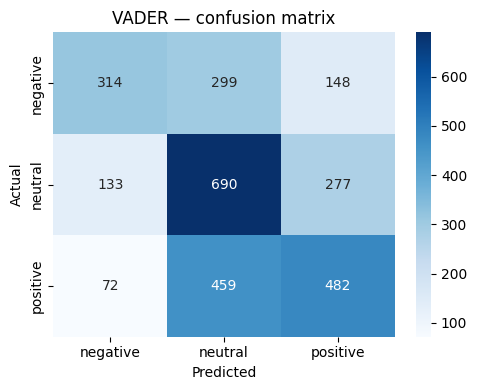

In [47]:
sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# VADER runs on substituted text, aligned with the test split index
X_test_raw = df.loc[X_test.index, 'substituted']
y_pred_vader = X_test_raw.apply(vader_predict)

evaluate('VADER', y_test, y_pred_vader)

### 4.2 TF-IDF + Naive Bayes

Unigrams, bigrams, and trigrams. Fit on training set only.

=== TF-IDF + Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.86      0.58      0.69       761
     neutral       0.71      0.78      0.75      1100
    positive       0.70      0.80      0.74      1013

    accuracy                           0.73      2874
   macro avg       0.76      0.72      0.73      2874
weighted avg       0.75      0.73      0.73      2874



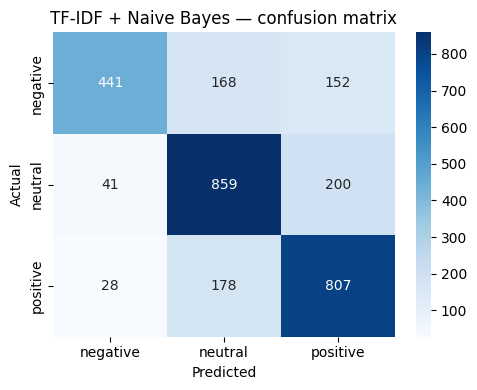

In [46]:
tfidf = TfidfVectorizer(ngram_range=(1, 3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

evaluate('TF-IDF + Naive Bayes', y_test, y_pred_nb)

### 4.3 TF-IDF + Logistic Regression

Same TF-IDF features as Naive Bayes. `max_iter=1000` to ensure convergence.

=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.83      0.70      0.76       761
     neutral       0.73      0.80      0.77      1100
    positive       0.78      0.79      0.79      1013

    accuracy                           0.77      2874
   macro avg       0.78      0.77      0.77      2874
weighted avg       0.78      0.77      0.77      2874



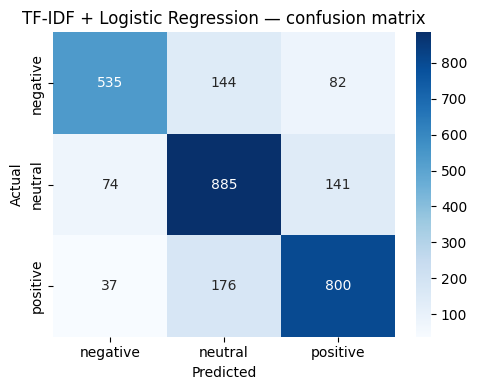

In [48]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

evaluate('TF-IDF + Logistic Regression', y_test, y_pred_lr)

### 4.4 Word2Vec + Logistic Regression

Word2Vec is trained on the training set only, producing a dense vector for each word. Each headline is represented as the average of its word vectors (average pooling). Headlines with no words in the vocabulary are represented as a zero vector. The averaged vectors are fed into Logistic Regression.

This captures semantic similarity between words — "profit" and "gain" end up close in vector space — which TF-IDF cannot. However, averaging loses word order, so "Target beats Other" and "Other beats Target" map to the same vector. The paper uses GloVe+LSTM, which preserves order; our approach is a simpler in-scope analogue.

=== Word2Vec + Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.50      0.22      0.31       761
     neutral       0.50      0.74      0.59      1100
    positive       0.48      0.42      0.45      1013

    accuracy                           0.49      2874
   macro avg       0.49      0.46      0.45      2874
weighted avg       0.49      0.49      0.47      2874



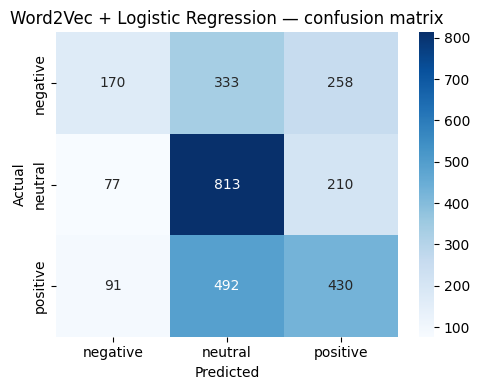

In [61]:
w2v = Word2Vec(sentences=train_sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

def avg_feature_vector(words, model, vector_size):
    vecs = [model.wv[w] for w in words if w in model.wv]
    if not vecs:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

X_train_w2v = np.array([avg_feature_vector(s, w2v, 100) for s in train_sentences])
X_test_w2v  = np.array([avg_feature_vector(s, w2v, 100) for s in test_sentences])

lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = lr_w2v.predict(X_test_w2v)

evaluate('Word2Vec + Logistic Regression', y_test, y_pred_w2v)

### 4.5 GloVe + Logistic Regression

Same average-pooling approach as Word2Vec, but using Stanford's pre-trained GloVe vectors (6B tokens, 100d) instead of vectors trained on this corpus. Pre-trained vectors capture richer semantic relationships because they were trained on a much larger and more varied corpus.

The technique (averaged embeddings + LR) is the same as section 4.4 and is used in the course notebooks (E6). The pre-trained vectors are outside course scope and flagged below.

In [55]:
# OUTSIDE COURSE SCOPE: using Stanford GloVe pre-trained vectors (glove.6B.100d.txt).
# The averaging + LR technique is from E6; only the pre-trained vectors are new.

glove_path = 'glove/glove.6B/glove.6B.100d.txt'
if os.path.exists(glove_path):
    print(f"Found {glove_path}")
else:
    print(f"File not found at {glove_path} — check the folder structure")

Found glove/glove.6B/glove.6B.100d.txt


GloVe vocabulary size: 400,000
=== GloVe + Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.66      0.56      0.60       761
     neutral       0.63      0.69      0.65      1100
    positive       0.61      0.62      0.62      1013

    accuracy                           0.63      2874
   macro avg       0.63      0.62      0.63      2874
weighted avg       0.63      0.63      0.63      2874



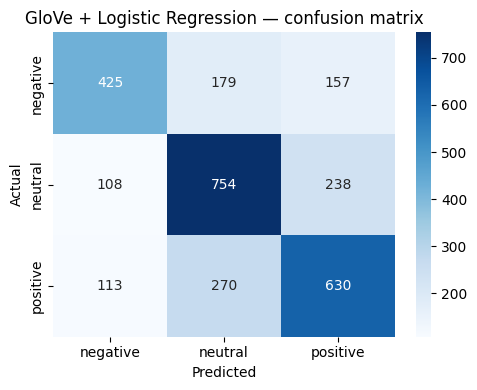

In [60]:
glove = {}
with open('glove/glove.6B/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)

print(f"GloVe vocabulary size: {len(glove):,}")

def avg_glove_vector(words, glove, vector_size=100):
    vecs = [glove[w.lower()] for w in words if w.lower() in glove]
    if not vecs:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

X_train_glove = np.array([avg_glove_vector(s, glove) for s in train_sentences])
X_test_glove  = np.array([avg_glove_vector(s, glove) for s in test_sentences])

lr_glove = LogisticRegression(max_iter=1000)
lr_glove.fit(X_train_glove, y_train)
y_pred_glove = lr_glove.predict(X_test_glove)

evaluate('GloVe + Logistic Regression', y_test, y_pred_glove)

### 4.6 GPT Zero-Shot (Frontier LLM)

Entity-aware zero-shot classification using the OpenAI API. The raw headline and entity name are passed directly in the prompt — no Target/Other substitution. The model is asked to output exactly one word. This tests whether a frontier LLM can perform entity-aware sentiment classification from a natural-language instruction alone, without any training or feature engineering.

In [35]:
# OUTSIDE COURSE SCOPE: using OpenAI API (GPT) for zero-shot classification.
# Not available in course tools; included to benchmark a frontier LLM baseline.
%pip install openai -q

import openai

# Set your API key here — do not commit this file with the key filled in
OPENAI_API_KEY = "REMOVED_API_KEY"
client = openai.OpenAI(api_key=OPENAI_API_KEY)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


  0/2874
  200/2874
  400/2874
  600/2874
  800/2874
  1000/2874
  1200/2874
  1400/2874
  1600/2874
  1800/2874
  2000/2874
  2200/2874
  2400/2874
  2600/2874
  2800/2874
=== GPT Zero-Shot ===
              precision    recall  f1-score   support

    negative       0.80      0.95      0.87       761
     neutral       0.91      0.57      0.70      1100
    positive       0.74      0.92      0.82      1013

    accuracy                           0.80      2874
   macro avg       0.81      0.82      0.80      2874
weighted avg       0.82      0.80      0.79      2874



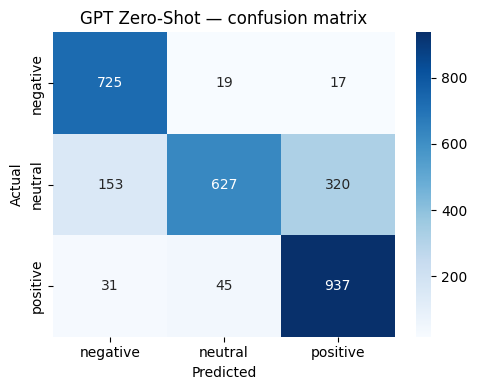

In [51]:
VALID = {'positive', 'negative', 'neutral'}

def gpt_predict(headline, entity, model='gpt-5-mini'):
    prompt = (
        f"Classify the sentiment towards {entity} in this financial news headline "
        f"as exactly one word: positive, negative, or neutral.\n\nHeadline: {headline}"
    )
    response = client.chat.completions.create(
        model=model,
        messages=[{'role': 'user', 'content': prompt}],
    )
    label = response.choices[0].message.content.strip().lower()
    return label if label in VALID else 'neutral'

# Retrieve original headlines and entities aligned with the test split
test_df = df.loc[X_test.index, ['headline', 'entity']].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

y_pred_gpt = []
for i, row in test_df.iterrows():
    y_pred_gpt.append(gpt_predict(row['headline'], row['entity']))
    time.sleep(0.05)
    if i % 200 == 0:
        print(f"  {i}/{len(test_df)}")

evaluate('GPT Zero-Shot', y_test_reset, y_pred_gpt)

### 4.7 Local LLM Zero-Shot (Qwen3-4B via NobodyWho)

Entity-aware zero-shot classification using a local Qwen3-4B model running via NobodyWho. Same prompt structure as GPT: raw headline and entity name, no Target/Other substitution. Runs fully offline. History is reset between each call to prevent context accumulation.

  0/2874
  200/2874
  400/2874
  600/2874
  800/2874
  1000/2874
  1200/2874
  1400/2874
  1600/2874
  1800/2874
  2000/2874
  2200/2874
  2400/2874
  2600/2874
  2800/2874
=== Local LLM Zero-Shot (Qwen3-4B) ===
              precision    recall  f1-score   support

    negative       0.68      0.94      0.79       761
     neutral       0.77      0.45      0.57      1100
    positive       0.71      0.82      0.76      1013

    accuracy                           0.71      2874
   macro avg       0.72      0.74      0.71      2874
weighted avg       0.72      0.71      0.69      2874



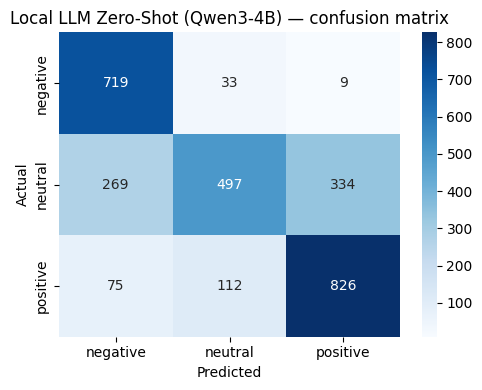

In [68]:
local_chat = nobodywho.Chat(
    "./Qwen_Qwen3-4B-Q4_K_M.gguf",
    system_prompt="You are a financial sentiment classifier. Classify the sentiment towards a named entity in a financial news headline. Reply with exactly one word: positive, negative, or neutral.",
    template_variables={"enable_thinking": False},
)

VALID_LOCAL = {'positive', 'negative', 'neutral'}

def local_predict(headline, entity):
    local_chat.reset_history()
    prompt = f"What is the sentiment towards {entity} in this headline: positive, negative, or neutral?\n\nHeadline: {headline}"
    response = local_chat.ask(prompt).completed()
    label = response.strip().lower()
    if label in VALID_LOCAL:
        return label
    for v in VALID_LOCAL:
        if v in label:
            return v
    return 'neutral'

y_pred_local = []
for i, row in test_df.iterrows():
    y_pred_local.append(local_predict(row['headline'], row['entity']))
    if i % 200 == 0:
        print(f"  {i}/{len(test_df)}")

evaluate('Local LLM Zero-Shot (Qwen3-4B)', y_test_reset, y_pred_local)

### 4.8 FinBERT Zero-Shot

FinBERT (`ProsusAI/finbert`) is a BERT model fine-tuned on financial text for sentiment classification. It receives the Target/Other substituted headline — the same entity-aware input as the trained models — and predicts positive, negative, or neutral without any further training on our dataset. The model downloads automatically on first run (~440 MB).

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 62905.17it/s]


=== FinBERT Zero-Shot ===
              precision    recall  f1-score   support

    negative       0.73      0.64      0.68       761
     neutral       0.56      0.77      0.65      1100
    positive       0.75      0.51      0.61      1013

    accuracy                           0.64      2874
   macro avg       0.68      0.64      0.64      2874
weighted avg       0.67      0.64      0.64      2874



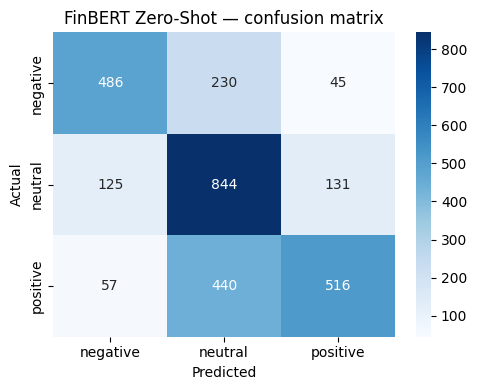

In [71]:
# OUTSIDE COURSE SCOPE: ProsusAI/finbert via HuggingFace transformers.
# Not available in course tools; included as a domain-specific pre-trained baseline.
finbert = hf_pipeline("text-classification", model="ProsusAI/finbert")

X_test_substituted = df.loc[X_test.index, 'substituted'].tolist()

raw_preds = finbert(X_test_substituted, batch_size=32, truncation=True)
y_pred_finbert = [p['label'].lower() for p in raw_preds]

evaluate('FinBERT Zero-Shot', y_test, y_pred_finbert)